# TissueNarrator — Perturb-FISH tutorial

Reproduces the spatial in-silico perturbation figures (Perturb-FISH THP1 tumor screen):

1. **Spatial perturbation map** — where the perturbed (KO) cells sit.
2. **Per-perturbation LFC** — for each of 11 leave-one-out knockouts,
   TissueNarrator's predicted neighbor-T-cell response (near-KO vs near-control)
   vs the ground-truth response, scored by Spearman ρ.

TN-only. Predictions come from saved generated cells (`k5` column = 5 samples/target;
we use the first). All inputs are in `tutorials/data/` — see `tutorials/data/README.md`.

> **Note.** Training TissueNarrator and running full inference take **days** on a GPU, so
> this notebook reconstructs the figures from saved generated cells rather than
> training/inferring from scratch. See [`01_preprocess`](01_preprocess.ipynb),
> [`02_train`](02_train.ipynb), and [`03_demo_inference`](03_demo_inference.ipynb) for
> end-to-end training and inference.

In [1]:
import sys
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq
from scipy.stats import spearmanr

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))
import tutorial_utils as tu
from tutorial_utils import data_path
tu.setup_style()

# Perturb-FISH reconstruction fit + LFC caps (dataset-specific).
TN_SLOPE, TN_INTERCEPT = -0.5460908807616134, 1.2497654139730365
LFC_CAP = 15.0   # outlier guard on per-gene Wilcoxon LFCs
PIXEL_UM = 0.108  # px -> µm
print("ready")

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


ready


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


In [2]:
# Ground-truth AnnData: scale to µm and build the 30 µm spatial graph.
a = ad.read_h5ad(data_path("pertfish_tumors_test.h5ad"))
a.obsm["spatial"] = a.obsm["spatial"] * PIXEL_UM
sq.gr.spatial_neighbors(a, coord_type="generic", radius=30)
genes = list(a.var_names)
is_t = (a.obs["celltype2"].astype(str) == "T cells").to_numpy()
print(a.shape, "| T cells:", int(is_t.sum()))

(154418, 154) | T cells: 39250


## Spatial perturbation map

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


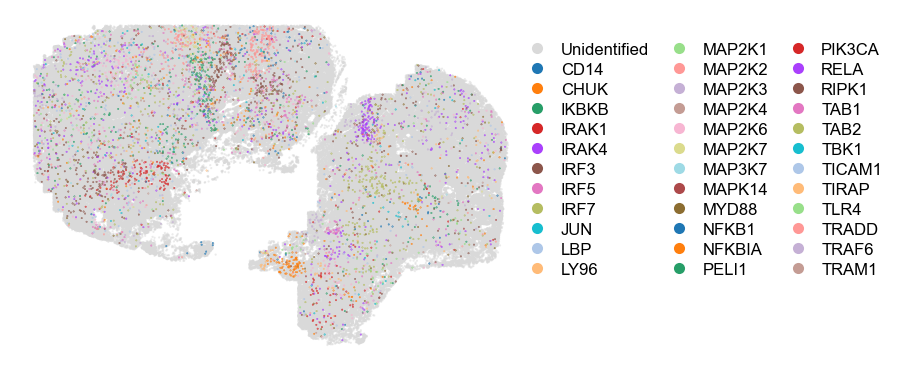

In [3]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

valid = (~a.obs["perturbation"].astype(str).str.contains("_", na=False)
         & (a.obs["perturbation"].astype(str) != "Control"))
ap = a[valid].copy()
ap.obs["perturbation_plot"] = ap.obs["perturbation"].astype("string")
ap.obs.loc[ap.obs["perturbation_plot"].isna(), "perturbation_plot"] = "Unidentified"
cats = ["Unidentified"] + sorted(c for c in ap.obs["perturbation_plot"].unique() if c != "Unidentified")
ap.obs["perturbation_plot"] = pd.Categorical(ap.obs["perturbation_plot"], categories=cats)
palette = ["#d9d9d9"] + list(sc.plotting.palettes.default_20 * ((len(cats) // 20) + 1))[: len(cats) - 1]
ap.uns["perturbation_plot_colors"] = palette

fig, ax = plt.subplots(figsize=(9, 11))
sq.pl.spatial_scatter(ap, color="perturbation_plot", groups=["Unidentified"], size=1.0, shape=None,
                      alpha=0.3, frameon=False, title="", legend_loc=None, ax=ax)
sq.pl.spatial_scatter(ap, color="perturbation_plot", groups=[c for c in cats if c != "Unidentified"],
                      shape=None, size=0.3, alpha=0.8, frameon=False, title="", legend_loc=None, ax=ax)
handles = [Line2D([], [], marker="o", linestyle="None", markersize=8, markerfacecolor=palette[i],
                  markeredgecolor="none", label=cats[i]) for i in range(len(cats))]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.95, 0.95), ncol=3, frameon=False,
          fontsize=12, handletextpad=0.4, columnspacing=0.8, labelspacing=0.3)
plt.tight_layout(); plt.show()

## Per-perturbation predicted vs ground-truth LFC

For each knockout we compute a per-gene log-fold-change between neighbor T cells near a
KO tumor vs near a control tumor — once from the ground-truth expression, once from
TissueNarrator's generated cells — then correlate them (Spearman ρ).

In [4]:
# LFC helpers (Wilcoxon near-KO vs near-control), and the linear full-panel reconstruction.
gidx = tu.gene_index(genes)

def recon_full(sentence):
    return tu.reconstruct_expression(tu.post_process_genes(sentence, genes, top_n=200),
                                     gidx, TN_SLOPE, TN_INTERCEPT)

def _lfc(adp, cap):
    sc.pp.filter_genes(adp, min_cells=5)
    sc.tl.rank_genes_groups(adp, "tg", method="wilcoxon", key_added="wx")
    r = adp.uns["wx"]
    lfc = pd.DataFrame({"gene": r["names"]["test"], "lfc": r["logfoldchanges"]["test"]})
    lfc = lfc[lfc["lfc"].abs() < cap]
    return dict(zip(lfc["gene"], lfc["lfc"]))

def gt_lfc(a, P):
    sc_ = a.obsp["spatial_connectivities"]
    pert = a.obs["perturbation"].astype(object).fillna("NA").astype(str).to_numpy()
    near_ko = np.asarray(sc_ @ (pert == P).astype(np.int8)[:, None]).ravel() > 0
    near_ctrl = np.asarray(sc_ @ (pert == "Control").astype(np.int8)[:, None]).ravel() > 0
    t_ko, t_ctrl = near_ko & is_t, near_ctrl & is_t
    keep = t_ko | t_ctrl
    sub = a[keep].copy()
    sub.obs["tg"] = np.where(t_ko[keep], "test", "control")
    return _lfc(sub, LFC_CAP)

def tn_lfc(gad):
    gad.obs["tg"] = np.where(gad.obs["cell_type"].to_numpy() == "near_KO", "test", "control")
    return _lfc(gad, LFC_CAP)
print("helpers ready")

helpers ready


In [5]:
ALL = ["CHUK","IRAK1","IRAK4","IRF7","LBP","MAP2K2","MAP2K6","MYD88","PELI1","TAB2","TRAM1"]
raw = pd.read_parquet(data_path("pertfish_lfc_raw.parquet"))
raws = {P: raw[raw["pert"] == P] for P in ALL}
# each row: a target T cell (tid), whether it is near a Control tumor (is_control),
# and k5 = 5 generated neighbor-T-cell gene rankings (we use the first sample)
print("raw columns:", list(raw.columns), "| rows:", len(raw))
print("example generated cell (k5[0]):", raw["k5"].iloc[0][0][:110])

# A target T cell that is near both a KO and a control tumor (across all perts) is
# dropped from the control side to keep the test asymmetric.
tid_types = defaultdict(set)
for P in ALL:
    for r in raws[P].itertuples(index=False):
        tid_types[r.tid].add("near_control" if r.is_control else "near_KO")
near_both = {t for t, s in tid_types.items() if len(s) > 1}
print(f"{len(ALL)} perts | near_both T cells: {len(near_both)}")

raw columns: ['tid', 'is_control', 'k5', 'pert'] | rows: 145199
example generated cell (k5[0]):  PKM ITGB1 MKI67 HDAC1 YAP1 STAT1 HIF1A CDK6 ETS1 TGFBI CTNNB1 EZH2 AURKA AKT3 WWTR1 VEGFC FOXM1 PLK1 MSH3 NFK
11 perts | near_both T cells: 1328


/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


CHUK: rho=0.546 p=2.30e-13 n=154


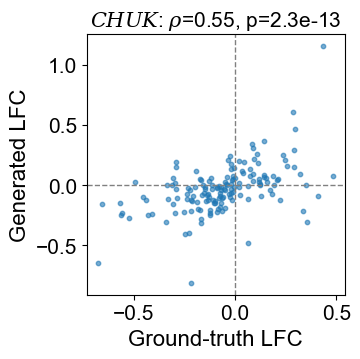

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


IRAK1: rho=0.361 p=4.33e-06 n=154


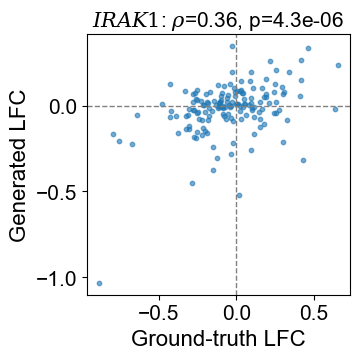

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


IRAK4: rho=0.110 p=1.74e-01 n=154


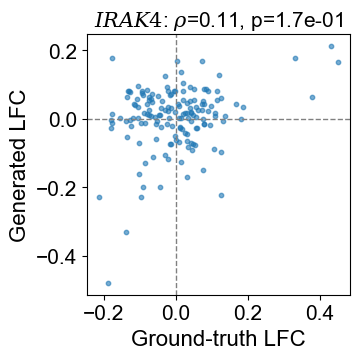

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


IRF7: rho=0.371 p=2.18e-06 n=154


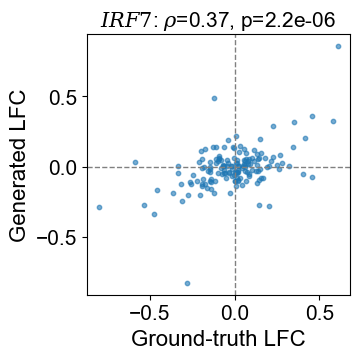

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


LBP: rho=0.426 p=3.51e-08 n=154


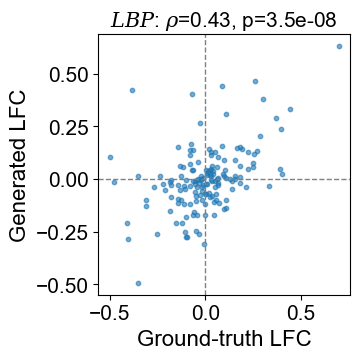

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


MAP2K2: rho=0.787 p=1.01e-33 n=154


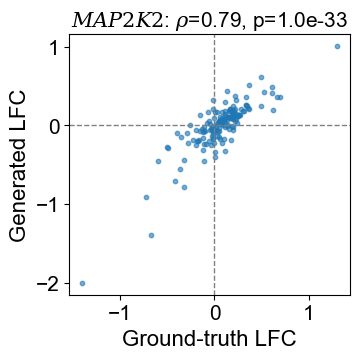

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


MAP2K6: rho=0.446 p=6.57e-09 n=154


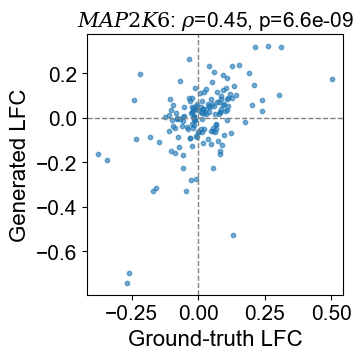

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


MYD88: rho=0.382 p=9.86e-07 n=154


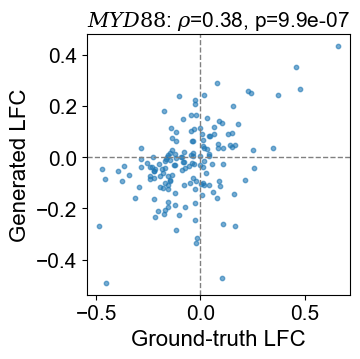

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


PELI1: rho=0.645 p=1.65e-19 n=154


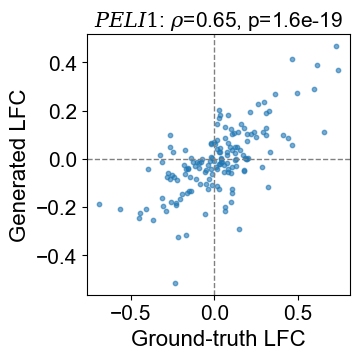

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


TAB2: rho=0.334 p=2.36e-05 n=154


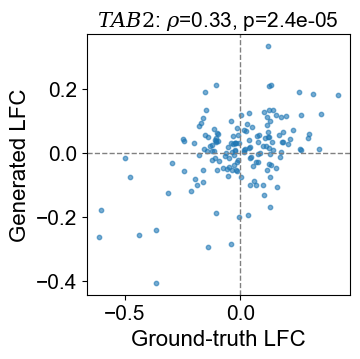

/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/sizheliu/miniconda3/envs/unsloth/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


TRAM1: rho=0.674 p=9.61e-22 n=154


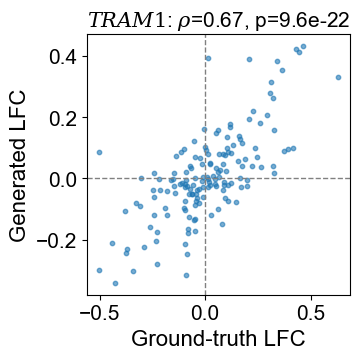


mean rho: 0.462


In [6]:
import matplotlib.pyplot as plt

results = {}
for P in ALL:
    rows = [(r.tid, bool(r.is_control), list(r.k5)) for r in raws[P].itertuples(index=False)]
    rows = [(t, ic, k) for (t, ic, k) in rows if not (ic and t in near_both)]
    X = np.stack([recon_full(k[0]) for _, _, k in rows]).astype(np.float32)
    obs = pd.DataFrame({"cell_type": ["near_control" if ic else "near_KO" for _, ic, _ in rows]},
                       index=pd.Index([t for t, _, _ in rows], name="tid"))
    gad = ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=genes))
    pl, gl = tn_lfc(gad), gt_lfc(a, P)
    g = [x for x in gl if x in pl]
    rho, pval = spearmanr([gl[x] for x in g], [pl[x] for x in g])
    results[P] = (rho, pval, len(g))
    print(f"{P}: rho={rho:.3f} p={pval:.2e} n={len(g)}")

    fig, ax = plt.subplots(figsize=(3.7, 3.7))
    ax.scatter([gl[x] for x in g], [pl[x] for x in g], s=10, alpha=0.6)
    ax.axhline(0, color="grey", lw=1, ls="--"); ax.axvline(0, color="grey", lw=1, ls="--")
    ax.set_xlabel("Ground-truth LFC", fontsize=16); ax.set_ylabel("Generated LFC", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=15)
    ax.set_title(rf"$\it{{{P}}}$: $\rho$={rho:.2f}, p={pval:.1e}", fontsize=15)
    plt.tight_layout(); plt.show()

print("\nmean rho:", round(np.mean([v[0] for v in results.values()]), 3))